# LIBRARY

In [1]:
import numpy as np
import pandas as pd
import gzip 
import pickle 
from collections import Counter
import matplotlib.pyplot as plt
import gzip
import pickle
import sys
import numpy as np
import warnings
import pandas as pd
from scipy.stats import levene
from statsmodels.tsa.stattools import adfuller, kpss
from sklearn.preprocessing import RobustScaler
from statsmodels.tsa.seasonal import STL
from statsmodels.tools.sm_exceptions import InterpolationWarning

warnings.simplefilter("ignore", InterpolationWarning)
warnings.simplefilter("ignore", UserWarning)



# DATAFRAMES

In [2]:
with gzip.open("../1.DATASET/CMI_timeseries_dataset.pkl.gz", "rb") as f:
	 CMI_timeseries_dataset = pickle.load(f)

In [3]:
# Check how many subjects/time series
print(f"Number of time series: {len(CMI_timeseries_dataset)}")

Number of time series: 4437


## FIRST ANALYSES

### COLUMNS

In [4]:
df = CMI_timeseries_dataset[0].copy()

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   X                    200 non-null    float32
 1   Y                    200 non-null    float32
 2   Z                    200 non-null    float32
 3   enmo                 200 non-null    float32
 4   anglez               200 non-null    float32
 5   non-wear_flag        200 non-null    float32
 6   light                200 non-null    float32
 7   battery_voltage      200 non-null    float32
 8   weekday              200 non-null    float64
 9   quarter              200 non-null    float64
 10  relative_date_PCIAT  200 non-null    float32
 11  id                   200 non-null    int64  
 12  sii_binary           200 non-null    int64  
dtypes: float32(9), float64(2), int64(2)
memory usage: 13.4 KB


### CLASS BALANCE

In [6]:
sii_distribution = [df['sii_binary'].iloc[0] for df in CMI_timeseries_dataset]
print(f"Class distribution: {sum(sii_distribution)} problematic, {len(sii_distribution)-sum(sii_distribution)} non-problematic")

Class distribution: 1480 problematic, 2957 non-problematic


### NULL VALUES

In [7]:
total_nulls = sum(df.isna().sum().sum() for df in CMI_timeseries_dataset)

if total_nulls == 0:
    print("No null values found in any DataFrame!")
else:
    print(f"Found {total_nulls} total null values")

No null values found in any DataFrame!


### UNIQUE VALUES

In [8]:
# attributes 
categorical_like = ['weekday', 'quarter', 'sii_binary', 'id', 'non-wear_flag']
continuous_like = ['X', 'Y', 'Z', 'enmo', 'anglez', 'light', 'battery_voltage', 'relative_date_PCIAT']

In [9]:
for col in categorical_like:
    all_values = sorted(set().union(*(df[col].unique() for df in CMI_timeseries_dataset)))
    print(f"\n{col}:\n   Unique values: {all_values}")


weekday:
   Unique values: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]

quarter:
   Unique values: [1.0, 2.0, 3.0, 4.0]

sii_binary:
   Unique values: [0, 1]

id:
   Unique values: [3, 25, 48, 51, 52, 63, 68, 82, 85, 90, 116, 118, 121, 129, 130, 132, 133, 134, 135, 140, 142, 150, 164, 167, 178, 179, 198, 200, 201, 206, 210, 214, 219, 220, 230, 231, 235, 239, 257, 270, 276, 277, 282, 284, 287, 300, 302, 310, 325, 339, 341, 347, 348, 354, 355, 367, 379, 380, 381, 382, 399, 407, 421, 428, 434, 459, 463, 465, 480, 503, 511, 514, 516, 520, 522, 523, 531, 537, 555, 558, 560, 566, 574, 575, 580, 599, 601, 606, 613, 633, 634, 642, 654, 657, 668, 670, 675, 681, 691, 692, 699, 706, 714, 717, 723, 732, 734, 735, 736, 739, 745, 749, 755, 764, 777, 783, 787, 789, 795, 797, 799, 828, 833, 835, 836, 839, 847, 851, 858, 861, 864, 881, 883, 884, 893, 894, 901, 910, 924, 929, 937, 941, 944, 956, 959, 969, 974, 975, 978, 981, 989, 996, 1008, 1011, 1014, 1017, 1024, 1027, 1028, 1035, 1044, 1050, 1054, 1056, 1069

In [10]:
for col in continuous_like:
    min_val, max_val = float('inf'), float('-inf')
    for df in CMI_timeseries_dataset:
        min_val, max_val = min(min_val, df[col].min()), max(max_val, df[col].max())
    print(f"\n{col}:\n   Range: [{min_val:.4f}, {max_val:.4f}]")


X:
   Range: [-8.0221, 1.3605]

Y:
   Range: [-2.0841, 1.5521]

Z:
   Range: [-1.0424, 8.0189]

enmo:
   Range: [0.0000, 7.0335]

anglez:
   Range: [-89.9032, 89.7458]

light:
   Range: [0.0000, 2594.6221]

battery_voltage:
   Range: [3099.0833, 6000.0000]

relative_date_PCIAT:
   Range: [-102.0000, 495.0000]


In [11]:
all_ids = [df['id'].iloc[0] for df in CMI_timeseries_dataset]
id_counts = Counter(all_ids)

In [12]:
print(f"{'-'*80}\nID FREQUENCY ANALYSIS\n{'-'*80}")
print(f"\nTotal DataFrames: {len(all_ids)}")
print(f"Unique IDs: {len(id_counts)}")
print(f"IDs appearing more than once: {sum(1 for c in id_counts.values() if c > 1)}")
print(f"IDs appearing only once: {sum(1 for c in id_counts.values() if c == 1)}")

--------------------------------------------------------------------------------
ID FREQUENCY ANALYSIS
--------------------------------------------------------------------------------

Total DataFrames: 4437
Unique IDs: 494
IDs appearing more than once: 253
IDs appearing only once: 241


In [13]:
# Filter for duplicates
duplicate_ids = {id_: count for id_, count in id_counts.items() if count > 1}

if duplicate_ids:
    # Extract only the items with the absolute highest and lowest repetitions
    max_id, max_count = max(duplicate_ids.items(), key=lambda x: x[1])
    min_id, min_count = min(duplicate_ids.items(), key=lambda x: x[1])
    
    print(f"\nIDs appear in multiple DataFrames:")
    print(f"   Maximum repetition -> ID {max_id}: appears {max_count} times")
    print(f"   Minimum repetition -> ID {min_id}: appears {min_count} times")



IDs appear in multiple DataFrames:
   Maximum repetition -> ID 2043: appears 36 times
   Minimum repetition -> ID 3186: appears 2 times


#### NON WEAR FLAG

In [14]:
groups = {'Always Wearing': [], 'Always Non-wear': [], 'Varying Pattern': []}
total = len(CMI_timeseries_dataset)

for df in CMI_timeseries_dataset:
    vals = df['non-wear_flag'].unique()
    target = df['sii_binary'].iloc[0]
    
    if len(vals) == 1:
        key = 'Always Wearing' if vals[0] == 0 else 'Always Non-wear'
    else:
        key = 'Varying Pattern'
    groups[key].append(target)

In [15]:
print(f"\nCategorization of {total} datasets:")
for name, cl in groups.items():
    print(f"  {name}: {len(cl)} ({len(cl)/total*100:.1f}%)")


Categorization of 4437 datasets:
  Always Wearing: 4258 (96.0%)
  Always Non-wear: 17 (0.4%)
  Varying Pattern: 162 (3.7%)


In [16]:
for name, cl in groups.items():
    if cl:
        prob = sum(cl)
        print(f"\nClass distribution for {name}:")
        print(f"  Problematic (sii_binary=1): {prob} ({prob/len(cl)*100:.1f}%)")
        print(f"  Non-problematic (sii_binary=0): {len(cl)-prob} ({(len(cl)-prob)/len(cl)*100:.1f}%)")


Class distribution for Always Wearing:
  Problematic (sii_binary=1): 1403 (32.9%)
  Non-problematic (sii_binary=0): 2855 (67.1%)

Class distribution for Always Non-wear:
  Problematic (sii_binary=1): 9 (52.9%)
  Non-problematic (sii_binary=0): 8 (47.1%)

Class distribution for Varying Pattern:
  Problematic (sii_binary=1): 68 (42.0%)
  Non-problematic (sii_binary=0): 94 (58.0%)


### STATISTICS

In [17]:
global_df = pd.concat(CMI_timeseries_dataset, ignore_index=True)
percentiles = [.01, .05, .10, .25, .50, .75, .90, .95, .99]
global_stats = global_df.describe(percentiles=percentiles)

print(f"GLOBAL DESCRIPTIVE STATISTICS (All Subjects Combined):\n")
print(global_stats)

GLOBAL DESCRIPTIVE STATISTICS (All Subjects Combined):

                   X              Y              Z           enmo  \
count  887400.000000  887400.000000  887400.000000  887400.000000   
mean       -0.092578       0.003362      -0.091223       0.056764   
std         0.538658       0.358403       0.423635       0.084195   
min        -8.022103      -2.084078      -1.042407       0.000000   
1%         -0.928149      -0.828171      -0.976485       0.000000   
5%         -0.809811      -0.601036      -0.785295       0.001043   
10%        -0.728483      -0.461969      -0.630218       0.004837   
25%        -0.571236      -0.230633      -0.364926       0.014106   
50%        -0.202865       0.002289      -0.114865       0.030716   
75%         0.435963       0.236372       0.152181       0.066491   
90%         0.658907       0.469673       0.490473       0.128631   
95%         0.759112       0.608892       0.695505       0.192282   
99%         0.913711       0.844721       0.983

In [18]:
global_df.shape

(887400, 13)

In [19]:
global_df[global_df['non-wear_flag']==0]

,X,Y,Z,enmo,anglez,non-wear_flag,light,battery_voltage,weekday,quarter,relative_date_PCIAT,id,sii_binary
0,-0.696639,-0.058477,-0.086717,0.051424,-6.090168,0.0,21.794674,4023.000000,4.0,4.0,253.0,2265,0
1,-0.479150,0.218840,-0.289497,0.062909,-19.893288,0.0,20.835835,4023.000000,4.0,4.0,253.0,2265,0
2,-0.440287,-0.171177,-0.326227,0.121546,-23.043303,0.0,6.294650,4023.000000,4.0,4.0,253.0,2265,0
3,-0.559035,-0.293204,-0.145227,0.084953,-9.694811,0.0,0.462963,4022.616699,4.0,4.0,253.0,2265,0
4,-0.531364,-0.210126,-0.086370,0.074157,-6.412807,0.0,4.058062,4020.583252,4.0,4.0,253.0,2265,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
887395,0.109243,0.581290,0.320458,0.056306,20.626949,0.0,13.580427,3689.000000,5.0,2.0,36.0,580,1
887396,-0.524706,0.227063,0.363919,0.081404,23.889679,0.0,13.534304,3689.000000,5.0,2.0,36.0,580,1
887397,-0.451121,-0.028637,0.405358,0.034749,25.322130,0.0,13.487847,3689.000000,5.0,2.0,36.0,580,1
887398,0.548647,0.177419,-0.791097,0.020374,-53.796261,0.0,13.441450,3689.000000,5.0,2.0,36.0,580,1


### INDIVIDUAL GRAPHICS

In [32]:
import matplotlib.pyplot as plt


def plot_subject_dashboard(dataset, target_id=None, dataset_idx=None):
    matched_dfs = []  # Stores tuples of (index, dataframe)

    # 1. Option A: Fetch by direct index position
    if dataset_idx is not None:
        if 0 <= dataset_idx < len(dataset):
            matched_dfs.append((dataset_idx, dataset[dataset_idx]))
        else:
            print(f"Dataset index {dataset_idx} is out of bounds.")
            return

    # 2. Option B: Collect ALL matching dataframes for this User ID
    elif target_id is not None:
        matched_dfs = [
            (idx, df)
            for idx, df in enumerate(dataset)
            if str(df["id"].iloc[0]) == str(target_id)
        ]

    # Guard clause if no datasets were found
    if not matched_dfs:
        print(f"No matching datasets found for the given criteria.")
        return

    # 3. Dynamic Side-by-Side Plotting Configuration
    n_matches = len(matched_dfs)
    # Get the columns from the first matched dataframe to calculate rows
    numeric_cols = matched_dfs[0][1].select_dtypes(include="number").columns
    n_rows = len(numeric_cols)

    # Create a dynamic grid: Rows = Features, Columns = Each appearance of the user
    fig, axes = plt.subplots(
        n_rows,
        n_matches,
        figsize=(5 * n_matches, 2 * n_rows),
        sharex=False,  # Can set to True now since all share the same 0-200 window
        squeeze=False,
    )

    # 4. Populate the subplots dynamically
    for col_idx, (ds_idx, df) in enumerate(matched_dfs):
        subj_id = df["id"].iloc[0]
        plot_df = df.select_dtypes(include="number")

        for row_idx, col_name in enumerate(numeric_cols):
            ax = axes[row_idx, col_idx]  # Fixed the walrus operator typo here

            # Plot the specific feature column sequence
            ax.plot(df[col_name].values, alpha=0.8)

            # ── CRITICAL ADDITION: FORCE X-AXIS SCALE 0 TO 200 ────────────────
            ax.set_xlim(0, 200)

            # Add titles only to the top row to keep layout clean
            if row_idx == 0:
                ax.set_title(
                    f"Appearance #{col_idx+1}\n(Dataset #{ds_idx})",
                    weight="bold",
                )

            # Add labels to the left-most plots
            if col_idx == 0:
                ax.set_ylabel(col_name, weight="bold")

            ax.grid(True, alpha=0.3)

    plt.suptitle(
        f"Side-by-Side Metrics Matrix for Subject {target_id if target_id else subj_id} ({n_matches} total appearances)",
        fontsize=14,
        weight="bold",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()

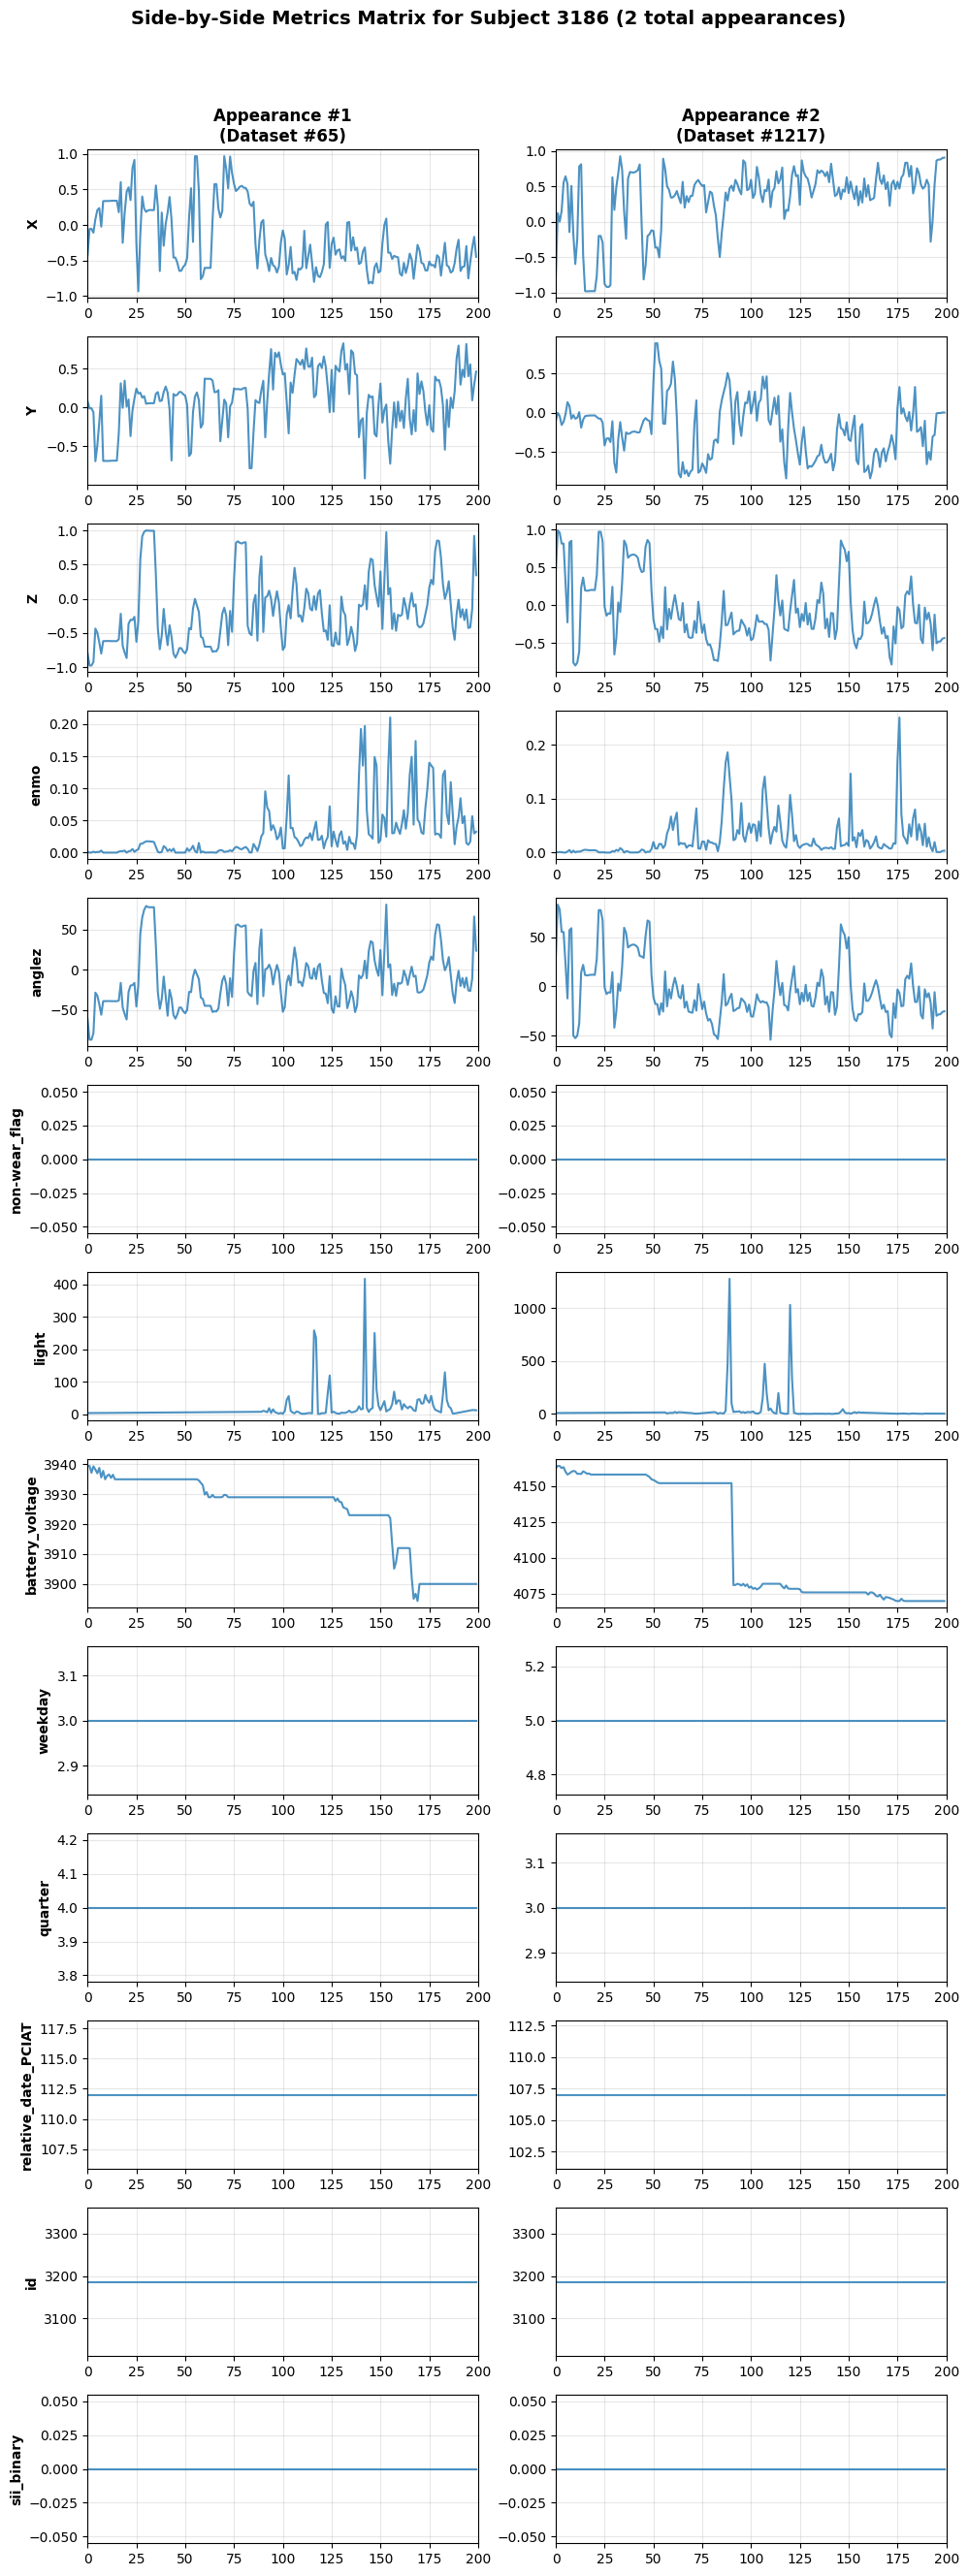

In [33]:
plot_subject_dashboard(CMI_timeseries_dataset, target_id="3186", dataset_idx=None)

# SELECTION


In [34]:
import numpy as np
kept_data, removed_data = [], []

for df in CMI_timeseries_dataset:
    if df["non-wear_flag"].mean() <= 0.5:
        kept_data.append(df)
    else:
        removed_data.append(df)

# Output summary metrics
print(f"Original: {len(CMI_timeseries_dataset)}")
print(f"Kept: {len(kept_data)} (always wear + mostly wear)")
print(f"Removed: {len(removed_data)} (mostly non-wear)")



Original: 4437
Kept: 4307 (always wear + mostly wear)
Removed: 130 (mostly non-wear)


In [35]:
# Compute distributions directly from the lists
orig_prob = sum(df["sii_binary"].iloc[0] for df in CMI_timeseries_dataset)
filt_prob = sum(df["sii_binary"].iloc[0] for df in kept_data)

print(f"\nProblematic: {orig_prob} → {filt_prob}")
print(
    f"Non-problematic: {len(CMI_timeseries_dataset)-orig_prob} → {len(kept_data)-filt_prob}"
)


Problematic: 1480 → 1420
Non-problematic: 2957 → 2887


In [36]:
analysis = []
for i, df in enumerate(CMI_timeseries_dataset):
    vals = df["non-wear_flag"].values
    mean_val = vals.mean()  # Fraction of time spent in non-wear state (1)

    # Only process subjects with actual varying patterns (contains both 0 and 1)
    if 0 < mean_val < 1:
        pct_wear = (1 - mean_val) * 100
        analysis.append(
            {
                "dataframe_idx": i,
                "id": df["id"].iloc[0],
                "sii_binary": df["sii_binary"].iloc[0],
                "class": (
                    "Problematic"
                    if df["sii_binary"].iloc[0] == 1
                    else "Non-problematic"
                ),
                "percent_wearing": pct_wear,
                "percent_non_wear": mean_val * 100,
                "transitions": np.sum(np.diff(vals) != 0),
                "dominant_state": 0 if pct_wear > 50 else 1,
                "dominant_label": (
                    "Mostly Wearing" if pct_wear > 50 else "Mostly Non-wear"
                ),
            }
        )

varying_df = pd.DataFrame(analysis)
total = len(varying_df)


In [37]:
print(f"Found {total} varying wear subjects\n\nSUMMARY\n")
# 1. High-level state distributions
m_wear = (varying_df["dominant_state"] == 0).sum()
print(f"Mostly Wearing: {m_wear} subjects ({m_wear/total*100:.1f}%)")
print(
    f"Mostly Non-wear: {total - m_wear} subjects ({(total - m_wear)/total*100:.1f}%)"
)

Found 162 varying wear subjects

SUMMARY

Mostly Wearing: 49 subjects (30.2%)
Mostly Non-wear: 113 subjects (69.8%)


In [38]:
print(
    f"\nMOSTLY NON-WEAR (>50%):\n{varying_df[varying_df['dominant_state'] == 1][['id', 'class', 'percent_non_wear', 'transitions']].to_string(index=False)}"
)
print(
    f"\nMOSTLY WEARING (>50%):\n{varying_df[varying_df['dominant_state'] == 0][['id', 'class', 'percent_wearing', 'transitions']].head(20).to_string(index=False)}"
)


MOSTLY NON-WEAR (>50%):
  id           class  percent_non_wear  transitions
  51     Problematic         95.499998           15
3847     Problematic         81.999999           15
1411 Non-problematic         73.745835           20
 881 Non-problematic         91.084725           14
 463     Problematic         96.669447           16
3520 Non-problematic         64.254165           27
1099 Non-problematic         92.500001           15
2251 Non-problematic         61.000001           32
2848 Non-problematic         84.254164            4
 198 Non-problematic         65.499997           31
2953 Non-problematic         98.500001            7
 789 Non-problematic         86.500001           36
1855     Problematic         88.000000           23
 606 Non-problematic         75.999999           32
 599 Non-problematic         78.254163           12
2779 Non-problematic         96.754164           11
 132 Non-problematic         71.499997           15
1657 Non-problematic         94.000000 

In [39]:
always_wear, mostly_wear = [], []
always_non_wear, mostly_non_wear = [], []
total = len(CMI_timeseries_dataset)

for df in CMI_timeseries_dataset:
    vals = df["non-wear_flag"].values
    non_wear_mean = vals.mean()  # Fraction of time spent not wearing device
    
    # Check if constant (either 0.0 or 1.0 exactly)
    is_constant = non_wear_mean == 0 or non_wear_mean == 1

    if non_wear_mean <= 0.5:  # Wear time >= 50% (KEEP)
        always_wear.append(df) if is_constant else mostly_wear.append(df)
    else:                     # Wear time < 50%  (DROP)
        always_non_wear.append(df) if is_constant else mostly_non_wear.append(df)

# Construct final subset and tracking aggregates
CMI_timeseries_filtered = always_wear + mostly_wear
n_keep, n_drop = len(CMI_timeseries_filtered), total - len(CMI_timeseries_filtered)

print(f"Dataset Composition (Total: {total})")
print(f"KEEP: Always wear: {len(always_wear)} | Mostly wear: {len(mostly_wear)} | Total: {n_keep} ({n_keep/total*100:.1f}%)")
print(f"DROP: Always non-wear: {len(always_non_wear)} | Mostly non-wear: {len(mostly_non_wear)} | Total: {n_drop} ({n_drop/total*100:.1f}%)")
print(f"Created filtered dataset with {n_keep} time series")

# Vectorized Class Distribution Checks
orig_prob = sum(df["sii_binary"].iloc[0] for df in CMI_timeseries_dataset)
filt_prob = sum(df["sii_binary"].iloc[0] for df in CMI_timeseries_filtered)
print(f"Class Distribution (Problematic):\n  Original: {orig_prob} ({orig_prob/total*100:.1f}%)\n  Filtered: {filt_prob} ({filt_prob/n_keep*100:.1f}%)")

# Compressed Storage dump
print(f" NEW DATA: CMI_timeseries_filtered")

Dataset Composition (Total: 4437)
KEEP: Always wear: 4258 | Mostly wear: 49 | Total: 4307 (97.1%)
DROP: Always non-wear: 17 | Mostly non-wear: 113 | Total: 130 (2.9%)
Created filtered dataset with 4307 time series
Class Distribution (Problematic):
  Original: 1480 (33.4%)
  Filtered: 1420 (33.0%)
 NEW DATA: CMI_timeseries_filtered


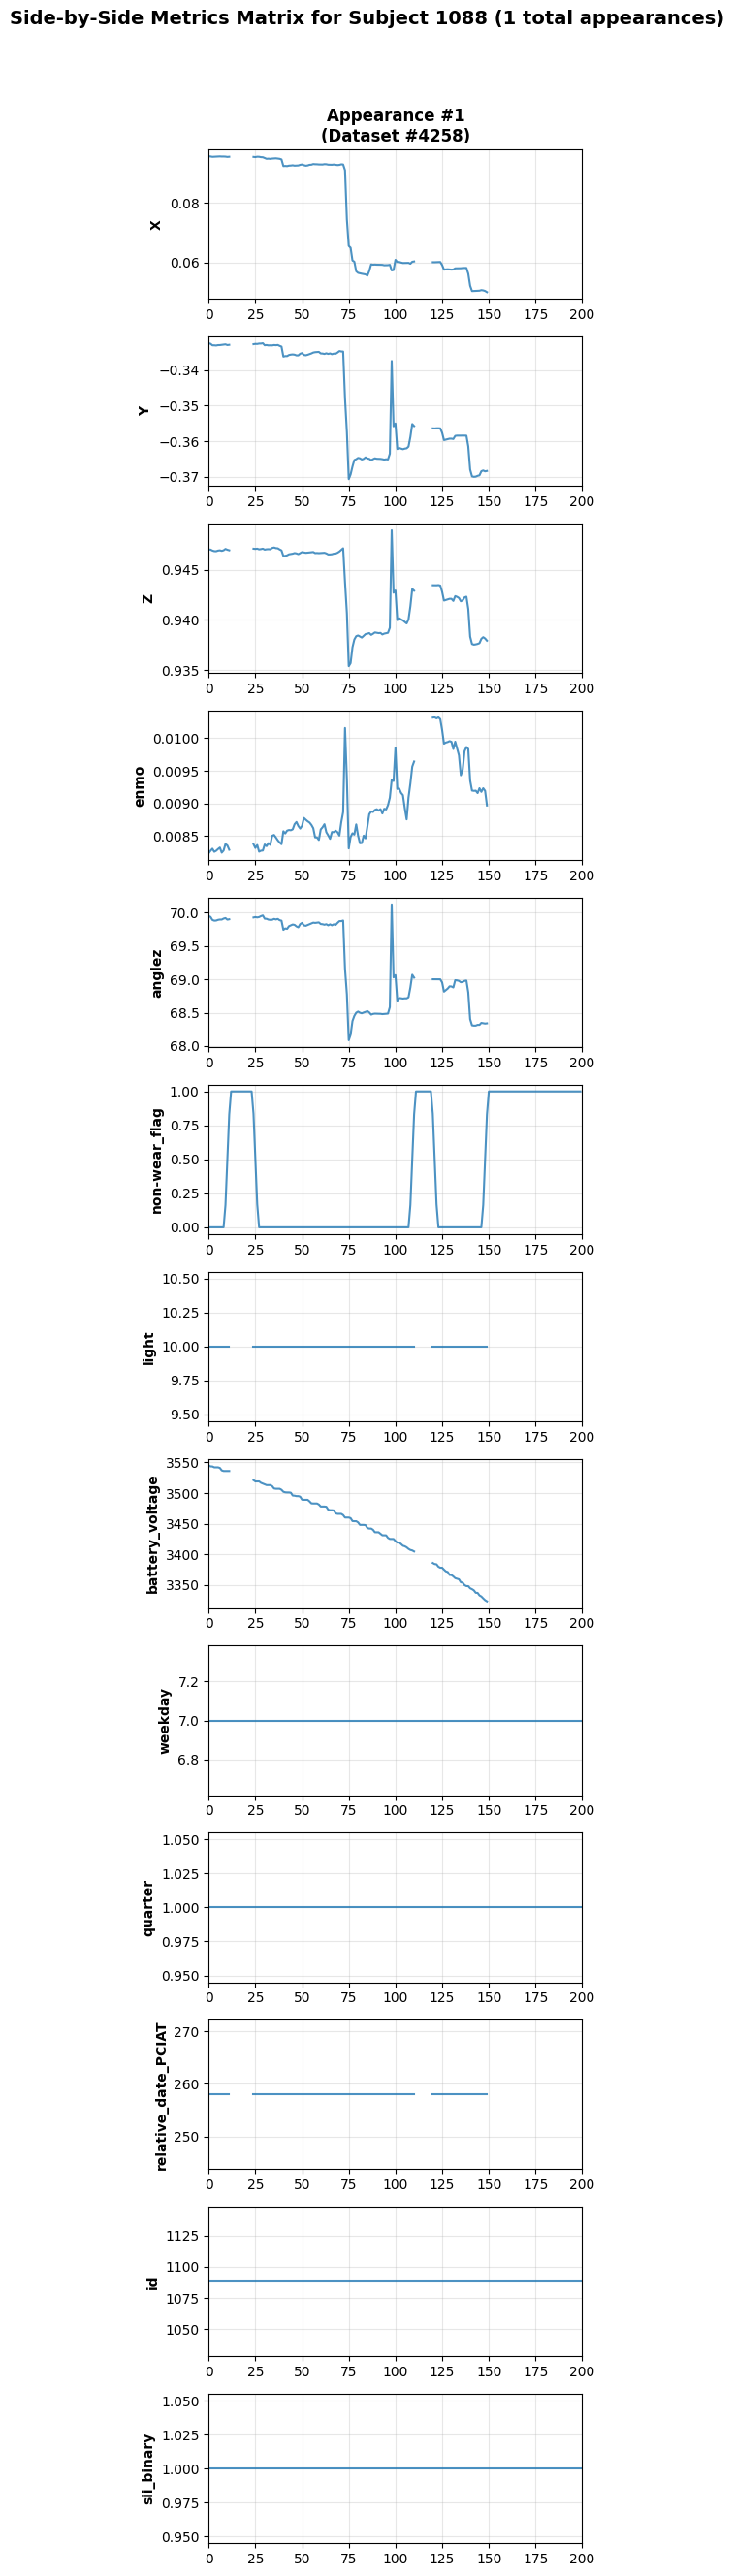

In [40]:
plot_subject_dashboard(CMI_timeseries_filtered, target_id="1088", dataset_idx=None)

## TRANSFORM NULL VALUES 

In [41]:
# Automatically detect available sensor columns (excluding metadata)
exclude = ["id", "sii_binary", "weekday", "quarter", "non-wear_flag"]
sensor_cols = [col for col in CMI_timeseries_filtered[0].columns if col not in exclude]

# Inline conversion using list comprehension and DataFrame assignment method
for df in CMI_timeseries_filtered:
    df.loc[df["non-wear_flag"] == 1, sensor_cols] = np.nan

print(f"Converted non-wear periods to NaN across {len(CMI_timeseries_filtered)} time series.")

Converted non-wear periods to NaN across 4307 time series.


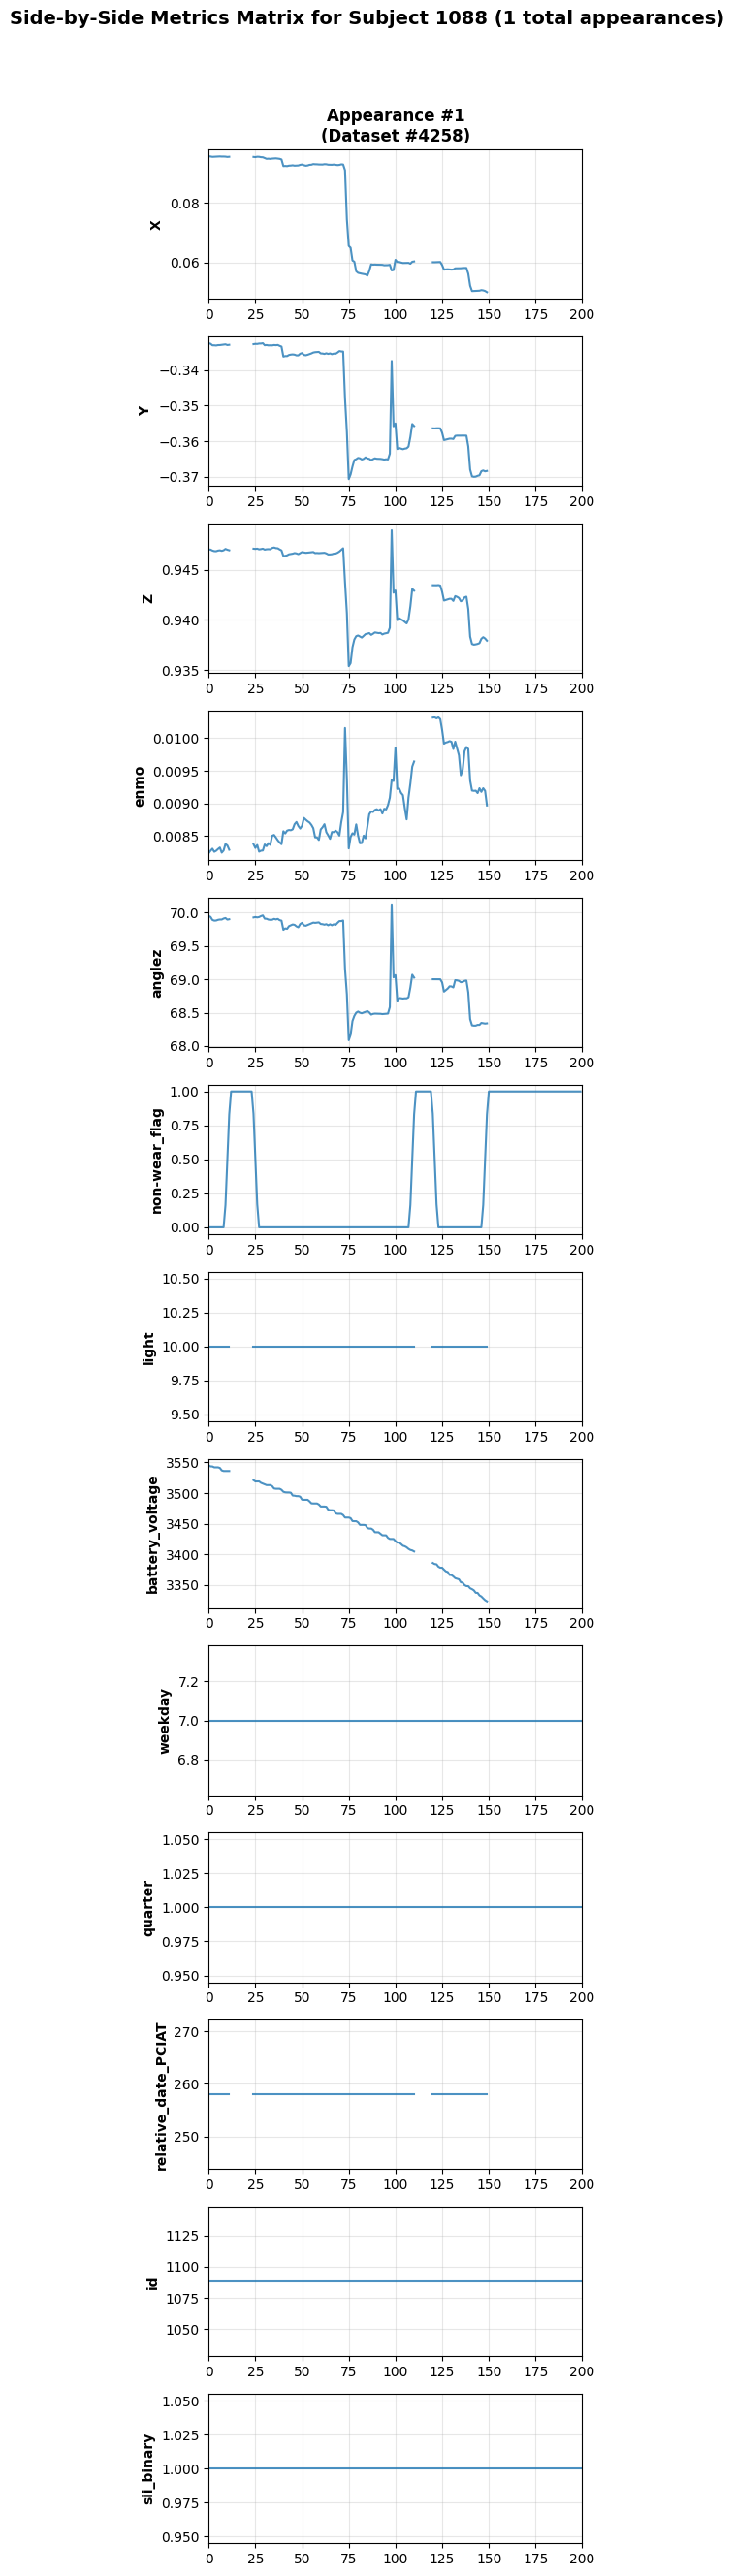

In [42]:
plot_subject_dashboard(CMI_timeseries_filtered, target_id="1088", dataset_idx=None)

## INTERPOLATION

In [45]:

for df in CMI_timeseries_filtered:
    df[sensor_cols] = df[sensor_cols].interpolate(
        method="linear", limit_direction="both"
    )

print(
    f"Successfully interpolated missing values across {len(CMI_timeseries_filtered)} time series."
)



Successfully interpolated missing values across 4307 time series.


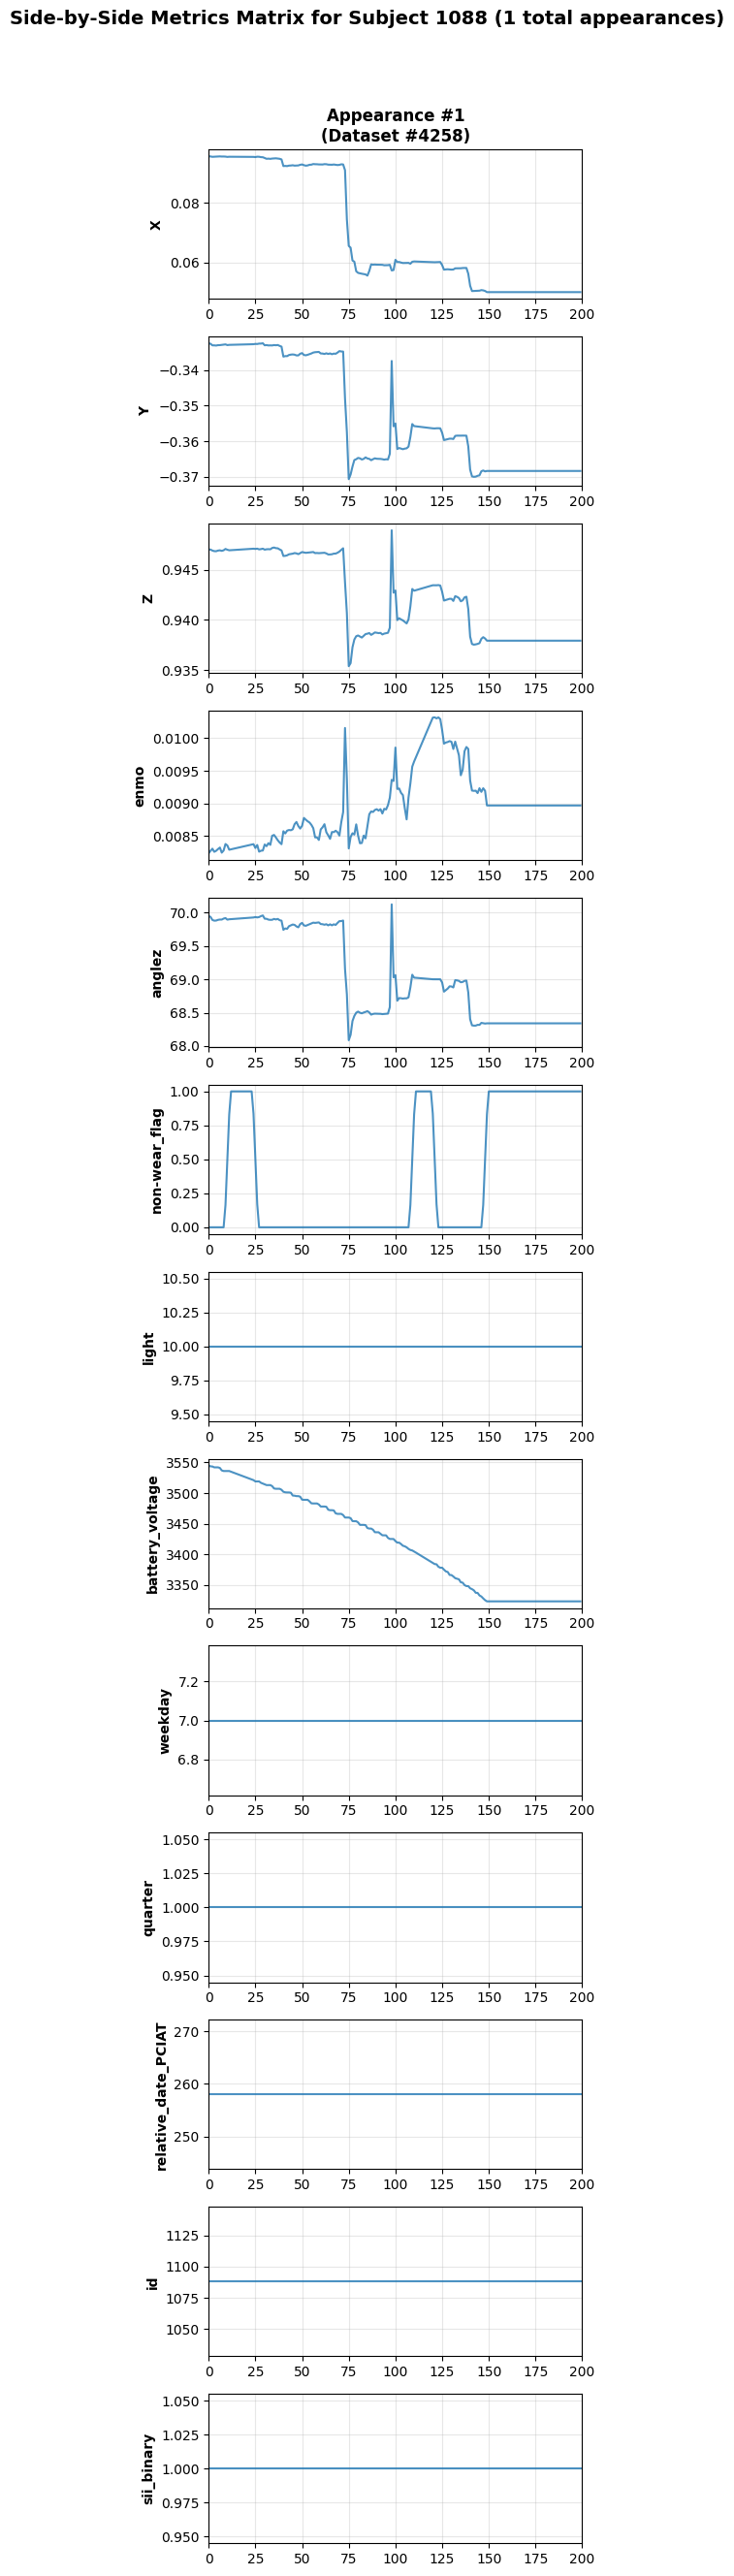

In [46]:
plot_subject_dashboard(CMI_timeseries_filtered, target_id="1088", dataset_idx=None)

# NORMALIZATION

## LOAD THE INTERPOLATED/CLEAN DATA

In [47]:
# Save
with gzip.open("../1.DATASET/CMI_timeseries_clean.pkl.gz", "wb") as f:
    pickle.dump(CMI_timeseries_filtered, f)

print(f"Saved: CMI_timeseries_clean.pkl.gz")

Saved: CMI_timeseries_clean.pkl.gz


In [48]:
# Check how many subjects/time series
with gzip.open("../1.DATASET/CMI_timeseries_clean.pkl.gz", "rb") as f:
	
	 data = pickle.load(f)
print(f"Number of time series: {len(data)}")
total_subjects = len(data) 

Number of time series: 4307


In [49]:
signals = [
    "enmo",
    "anglez",
    "light",
    "X",
    "Y",
    "Z",
    "battery_voltage",
    "relative_date_PCIAT",
]
results = {}

## PARAMETERS

In [69]:
N_PERMUTATIONS = 100  # The number of times the function shuffles your time series to build a baseline profile of random chance noise.
SEASONALITY_LAG = 48  # 24-hour cycle - 48 steps equal exactly 24 hours
HETERO_WINDOW = 48  # 24-hour window for variance

# Much stricter alphas to stop tests from flagging minor variations
ADF_ALPHA = 0.001  # Extemely strict trend detection  To confirm a trend exists, the $p$-value from the ADF test must be very high
KPSS_ALPHA = 0.01 #  and the $p$-value from the KPSS test must be lower than 0.01. 
LEVENE_ALPHA = 0.01  # Low alpha prevents over-applying log1p # low value like 0.01 means the variance difference must be massive before the code triggers log1p.


## SEASONALITY THRESHOLD GENERATOR

In [70]:
def get_local_acf_threshold(ts, lag, n_perm=N_PERMUTATIONS):
    n_elements = len(ts)
    if n_elements <= lag:
        return 0.0
    rng = np.random.default_rng()
    shuffled_indices = [rng.permutation(n_elements) for _ in range(n_perm)]
    surrogate_corrs = [
        abs(np.corrcoef(ts[idxs][:-lag], ts[idxs][lag:])[0, 1])
        for idxs in shuffled_indices
    ]
    clean_corrs = [c for c in surrogate_corrs if not np.isnan(c)]
    # Use 99th percentile instead of 95th to set a much higher bar for seasonality
    return np.percentile(clean_corrs, 99) if clean_corrs else 0.0

## DIAGNOSTIC PASS PER ID

In [71]:
TARGET_ID = "1088" 
target_df = None
for df in data:
    if str(df["id"].iloc[0]) == str(TARGET_ID):
        target_df = df.copy()
        break

In [55]:
target_df

,X,Y,Z,enmo,anglez,non-wear_flag,light,battery_voltage,weekday,quarter,relative_date_PCIAT,id,sii_binary
0,0.095634,-0.332481,0.947009,0.008238,69.950386,0.0,10.0,3545.108398,7.0,1.0,258.0,1088,1
1,0.095556,-0.332615,0.946999,0.008275,69.937263,0.0,10.0,3543.600098,7.0,1.0,258.0,1088,1
2,0.095439,-0.333056,0.946900,0.008307,69.891380,0.0,10.0,3543.416748,7.0,1.0,258.0,1088,1
3,0.095472,-0.333064,0.946844,0.008260,69.880753,0.0,10.0,3542.000000,7.0,1.0,258.0,1088,1
4,0.095541,-0.333116,0.946835,0.008276,69.882484,0.0,10.0,3542.000000,7.0,1.0,258.0,1088,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0.050164,-0.368370,0.937919,0.008970,68.340073,1.0,10.0,3323.050049,7.0,1.0,258.0,1088,1
196,0.050164,-0.368370,0.937919,0.008970,68.340073,1.0,10.0,3323.050049,7.0,1.0,258.0,1088,1
197,0.050164,-0.368370,0.937919,0.008970,68.340073,1.0,10.0,3323.050049,7.0,1.0,258.0,1088,1
198,0.050164,-0.368370,0.937919,0.008970,68.340073,1.0,10.0,3323.050049,7.0,1.0,258.0,1088,1


In [72]:
TREND_ALLOWED_SIGNALS = ["battery_voltage", "relative_date_PCIAT"]
LOG_ALLOWED_SIGNALS = ["enmo","anglez","light", "X", "Y", "Z"]
SEASONAL_ALLOWED_SIGNALS = ["enmo", "anglez", "light", "X", "Y", "Z", "battery_voltage"]

In [73]:
CMI_timeseries_personalized = []
if target_df is None:
    print(f"Could not find a dataset with ID: {TARGET_ID}")
else:
    print(f"{'='*70}\nANALYZING AND TRANSFORMING ID: {TARGET_ID}\n{'='*70}")

    local_transforms_applied = {"log1p": 0, "detrend": 0, "deseasonal": 0}

    for signal in signals:
        if signal not in target_df.columns:
            continue

        # 1. Grab the fully interpolated continuous signal array
        y = target_df[signal].values
        n_samples = len(y)

        # 2. SIMPLE LENGTH & FLATNESS GUARD - validate the signal
        if n_samples < SEASONALITY_LAG + 10 or np.ptp(y) == 0:
            continue
        if np.std(y) < 0.01:
            continue

        # ── STEP 1: INDIVIDUAL DIAGNOSIS ON THE ENTIRE SIGNAL ────────────────
        
        # Heteroscedasticity Test
        need_log1p = False
        if signal in LOG_ALLOWED_SIGNALS:
            n_blocks = n_samples // HETERO_WINDOW
            if n_blocks >= 3:
                blocks = np.reshape(y[: n_blocks * HETERO_WINDOW], (n_blocks, HETERO_WINDOW))
                _, levene_p = levene(*blocks, center="median")
                need_log1p = levene_p < LEVENE_ALPHA

        # Trend Test
        # Accelerometers shift positions in steps when a person moves or changes posture; they do not experience long-term linear drift.
        need_detrend = False
        if signal in TREND_ALLOWED_SIGNALS:
            try:
                adf_p = adfuller(y, autolag="AIC")[1]
                kpss_p = kpss(y, regression="c", nlags="auto")[1]
                need_detrend = (adf_p > ADF_ALPHA) and (kpss_p < KPSS_ALPHA)
            except:
                need_detrend = False

        # Seasonality Test
        need_deseasonal = False
        if signal in SEASONAL_ALLOWED_SIGNALS:
            try:
                real_corr = np.corrcoef(y[:-SEASONALITY_LAG], y[SEASONALITY_LAG:])[0, 1]
                threshold = get_local_acf_threshold(y, SEASONALITY_LAG)
                need_deseasonal = abs(real_corr) > (threshold * 1.3)
            except:
                need_deseasonal = False

        
        # ── STEP 2: TREATMENT ON THE ENTIRE SIGNAL ───────────────────────────
        print(
            f"Signal '{signal:<18}' | log1p: {str(need_log1p):<5} | detrend: {str(need_detrend):<5} | deseasonal: {str(need_deseasonal):<5}"
        )

        if need_log1p:
            y = np.log1p(np.maximum(0, y))
            local_transforms_applied["log1p"] += 1

        if need_detrend:
            x = np.arange(len(y))
            slope, intercept = np.polyfit(x, y, 1)
            if abs(slope) > 0.001:
                y = y - (slope * x + intercept)
            local_transforms_applied["detrend"] += 1

        if need_deseasonal:
            try:
                res = STL(y, period=48, robust=True, seasonal=13, trend=49).fit()
                y = y - res.seasonal
                local_transforms_applied["deseasonal"] += 1
            except:
                pass

        # Final uniform scaling across the whole continuous array
        scaler = RobustScaler()
        target_df[signal] = scaler.fit_transform(y.reshape(-1, 1)).flatten()

    CMI_timeseries_personalized.append(target_df)
    print(f"\n{'='*70}\n✨ TRANSFORMATION COMPLETED FOR SUBJECT: {TARGET_ID}")
    print(f"{'='*70}")

ANALYZING AND TRANSFORMING ID: 1088
Signal 'anglez            ' | log1p: True  | detrend: False | deseasonal: True 
Signal 'X                 ' | log1p: True  | detrend: False | deseasonal: True 
Signal 'Y                 ' | log1p: True  | detrend: False | deseasonal: True 
Signal 'battery_voltage   ' | log1p: False | detrend: False | deseasonal: True 

✨ TRANSFORMATION COMPLETED FOR SUBJECT: 1088


## DIAGNOSTIC PASS ALL

In [88]:
CMI_timeseries_personalized = []
# Track transformation counts globally just for your final insight
total_transforms_applied = {"log1p": 0, "detrend": 0, "deseasonal": 0}

for i, df in enumerate(data):
    df_clean = df.copy()
    subject_id = df_clean["id"].iloc[0]

    # Progress tracking indicator
    if (i + 1) % 50 == 0 or (i + 1) == total_subjects:
        sys.stdout.write(
            f"\r Prrc: {i + 1}/{total_subjects} subjects..."
        )
        sys.stdout.flush()

    for signal in signals:
        if signal not in df_clean.columns:
            continue

        y = df_clean[signal].values
        n_samples = len(y)

        # Skip logic if data is completely flat or empty
        if n_samples < SEASONALITY_LAG + 10 or np.ptp(y) == 0:
            continue

        # ── EXPLICIT FIX FOR ACCELEROMETER METADATA ──
        # If the standard deviation is tiny, don't run heavy math, it's safe as-is
        if np.std(y) < 0.01:
            continue

        # ── STEP 1: LIVE INDIVIDUAL DIAGNOSIS ────────────────────────────────
        # We test this specific vector right now to see what it needs
        
        # Check Heteroscedasticity (Does THIS subject need variance stabilization?)
        n_blocks = n_samples // HETERO_WINDOW
        need_log1p = False
        if n_blocks >= 3:
            blocks = np.reshape(
                y[: n_blocks * HETERO_WINDOW], (n_blocks, HETERO_WINDOW)
            )
            _, levene_p = levene(*blocks, center="median")
            need_log1p = levene_p < LEVENE_ALPHA

        # Check Trend (Does THIS subject have a linear drift?)
        try:
            adf_p = adfuller(y, autolag="AIC")[1]
            kpss_p = kpss(y, regression="c", nlags="auto")[1]
            need_detrend = (adf_p > ADF_ALPHA) and (kpss_p < KPSS_ALPHA)
        except:
            need_detrend = False

        # Check Seasonality (Is THIS subject experiencing a 24h periodic wave?)
        try:
            real_corr = np.corrcoef(y[:-SEASONALITY_LAG], y[SEASONALITY_LAG:])[
                0, 1
            ]
            threshold = get_local_acf_threshold(y, SEASONALITY_LAG)
            need_deseasonal = abs(real_corr) > threshold
        except:
            need_deseasonal = False

        # ── STEP 2: LIVE INDIVIDUAL TREATMENT ────────────────────────────────
        # Apply the changes purely based on the local booleans calculated above
        
        if need_log1p:
            y = np.log1p(np.maximum(0, y))
            total_transforms_applied["log1p"] += 1

        if need_detrend:
            x = np.arange(len(y))
            slope, intercept = np.polyfit(x, y, 1)
            if abs(slope) > 0.001:
                y = y - (slope * x + intercept)
            total_transforms_applied["detrend"] += 1

        if need_deseasonal:
            try:
                res = STL(y, period=48, robust=True, seasonal=13, trend=49).fit()
                y = y - res.seasonal
                total_transforms_applied["deseasonal"] += 1
            except:
                pass

        # Every signal still gets a final scaling so the dimensions match for the ML model
        scaler = RobustScaler()
        df_clean[signal] = scaler.fit_transform(y.reshape(-1, 1)).flatten()

    CMI_timeseries_personalized.append(df_clean)

print("\n\nSUCCESS: All data customized individually.")
print(f"Total Custom log1p applied: {total_transforms_applied['log1p']}")
print(f"Total Custom Detrends applied: {total_transforms_applied['detrend']}")
print(
    f"Total Custom Deseasonalizations applied: {total_transforms_applied['deseasonal']}"
)

 Prrc: 1250/4307 subjects...

c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


 Prrc: 2750/4307 subjects...

c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


 Prrc: 3850/4307 subjects...

c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


 Prrc: 4307/4307 subjects...

SUCCESS: All data customized individually.
Total Custom log1p applied: 22734
Total Custom Detrends applied: 0
Total Custom Deseasonalizations applied: 7751


## save

In [89]:
output_filename = "CMI_timeseries_personalized.pkl.gz"
print(f"\nSaving {output_filename}...")

with gzip.open(output_filename, "wb") as f:
    pickle.dump(CMI_timeseries_personalized, f)



Saving CMI_timeseries_personalized.pkl.gz...


## GRAPHICS

In [74]:
CMI_timeseries_personalized

[            X    Y         Z      enmo    anglez  non-wear_flag  light  \
 0    0.848127  0.0  0.947009  0.008238  0.757873            0.0   10.0   
 1    0.840870  0.0  0.946999  0.008275  0.724524            0.0   10.0   
 2    0.836426  0.0  0.946900  0.008307  0.703431            0.0   10.0   
 3    0.837321  0.0  0.946844  0.008260  0.709810            0.0   10.0   
 4    0.835587  0.0  0.946835  0.008276  0.709122            0.0   10.0   
 ..        ...  ...       ...       ...       ...            ...    ...   
 195 -0.235099  0.0  0.937919  0.008970 -0.315962            1.0   10.0   
 196 -0.233402  0.0  0.937919  0.008970 -0.315881            1.0   10.0   
 197 -0.229797  0.0  0.937919  0.008970 -0.320546            1.0   10.0   
 198 -0.230251  0.0  0.937919  0.008970 -0.323807            1.0   10.0   
 199 -0.231599  0.0  0.937919  0.008970 -0.321775            1.0   10.0   
 
      battery_voltage  weekday  quarter  relative_date_PCIAT    id  sii_binary  
 0           0.79

In [75]:
all_ids = [df['id'].iloc[0] for df in CMI_timeseries_personalized]
id_counts = Counter(all_ids)

In [76]:
print(f"{'-'*80}\nID FREQUENCY ANALYSIS\n{'-'*80}")
print(f"\nTotal DataFrames: {len(all_ids)}")
print(f"Unique IDs: {len(id_counts)}")
print(f"IDs appearing more than once: {sum(1 for c in id_counts.values() if c > 1)}")
print(f"IDs appearing only once: {sum(1 for c in id_counts.values() if c == 1)}")

--------------------------------------------------------------------------------
ID FREQUENCY ANALYSIS
--------------------------------------------------------------------------------

Total DataFrames: 1
Unique IDs: 1
IDs appearing more than once: 0
IDs appearing only once: 1


In [77]:
id_counts

Counter({1088: 1})

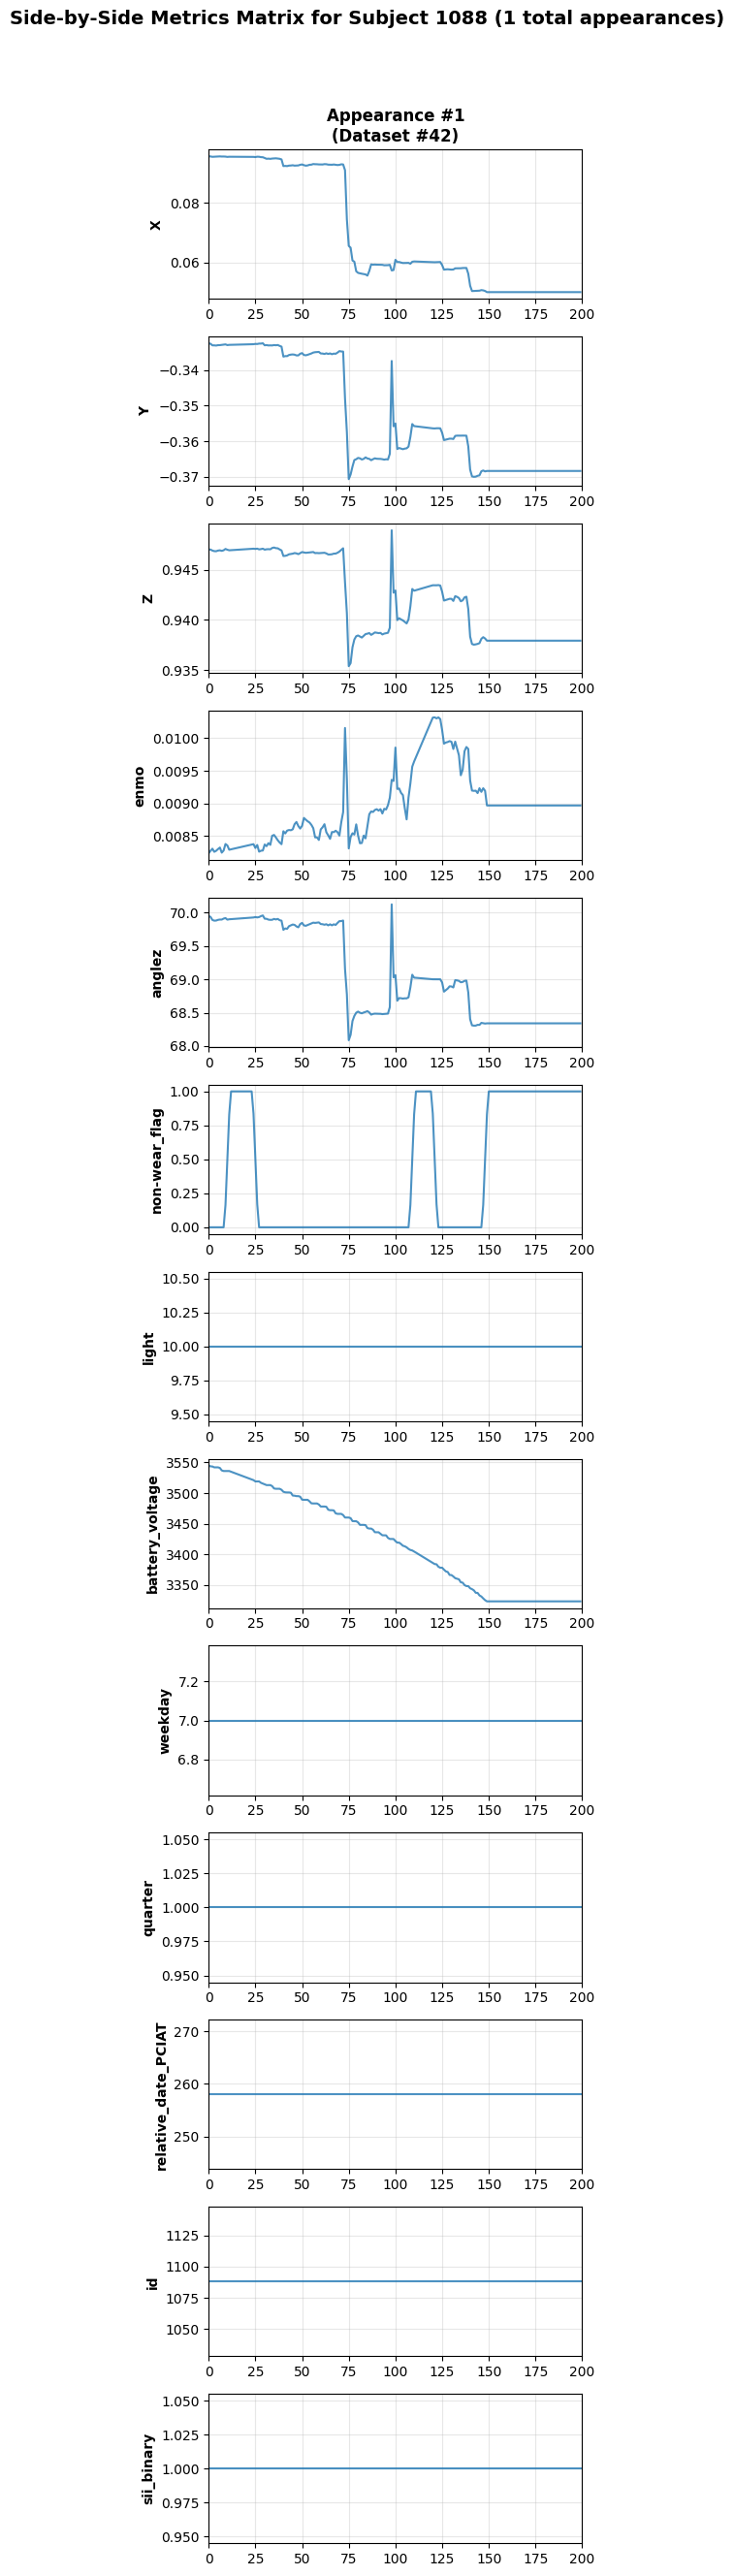

In [78]:
plot_subject_dashboard(CMI_timeseries_dataset, target_id="1088", dataset_idx=None)

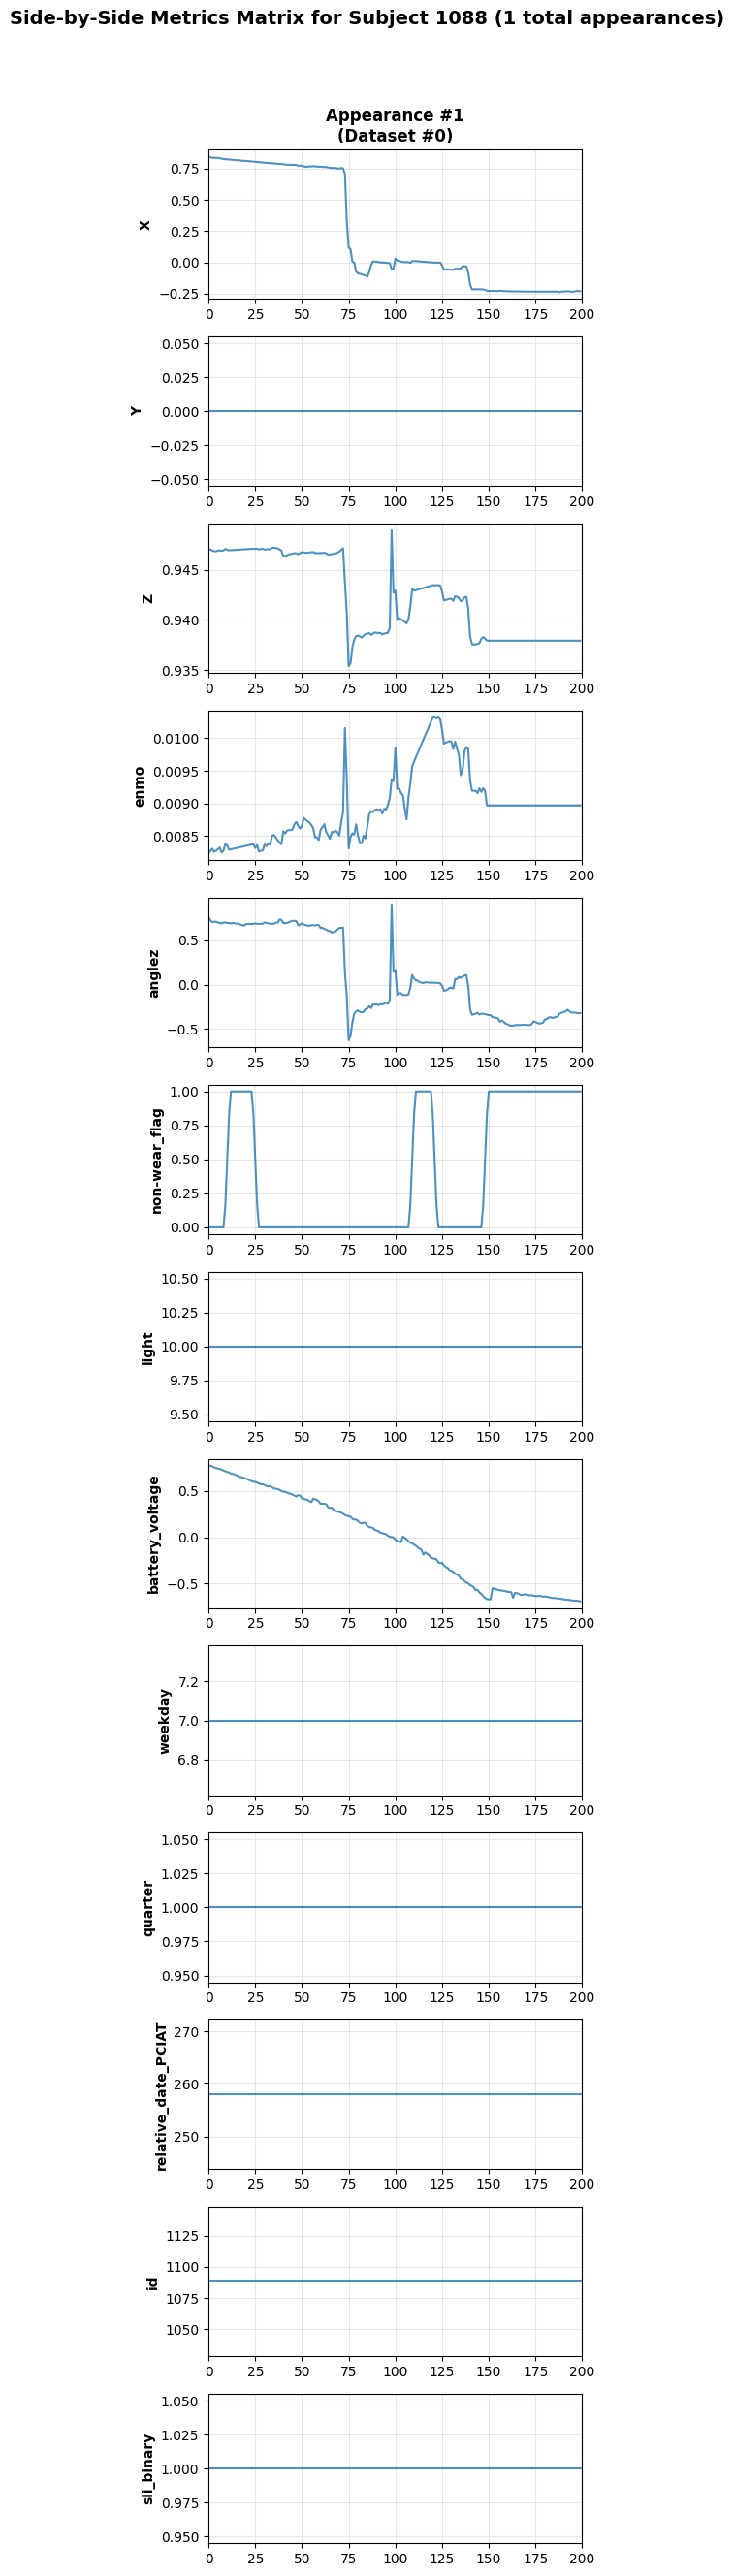

In [66]:
plot_subject_dashboard(CMI_timeseries_personalized, target_id="1088", dataset_idx=None)